In [1]:
# ============================================================
# WEEK 8 CAPSTONE PROJECT
# TITANIC SURVIVAL PREDICTION
# ============================================================

# ============================================================
# STEP 1 — PROJECT SETUP & DATA LOADING
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split
)

np.random.seed(42)

print("="*60)
print("LOADING TITANIC DATASET")
print("="*60)

# ============================================================
# LOAD DATA
# ============================================================

train_df = pd.read_csv("train.csv")

test_df = pd.read_csv("test.csv")

# ============================================================
# DATASET SHAPES
# ============================================================

print("\nTraining Shape:")
print(train_df.shape)

print("\nTesting Shape:")
print(test_df.shape)

# ============================================================
# PREVIEW DATA
# ============================================================

print("\nTraining Dataset Preview")

display(
    train_df.head()
)

print("\nTesting Dataset Preview")

display(
    test_df.head()
)

# ============================================================
# COLUMN INFORMATION
# ============================================================

print("\nTraining Columns")

print(
    train_df.columns.tolist()
)

print("\nTarget Variable")

print("Survived")

print("""
OBSERVATION:

The Titanic dataset contains passenger demographic
and travel information. The goal is to predict
whether a passenger survived the disaster using
machine learning techniques.
""")

LOADING TITANIC DATASET

Training Shape:
(891, 12)

Testing Shape:
(418, 11)

Training Dataset Preview


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Testing Dataset Preview


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Training Columns
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target Variable
Survived

OBSERVATION:

The Titanic dataset contains passenger demographic
and travel information. The goal is to predict
whether a passenger survived the disaster using
machine learning techniques.



DATASET OVERVIEW

Training Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values Summary


,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


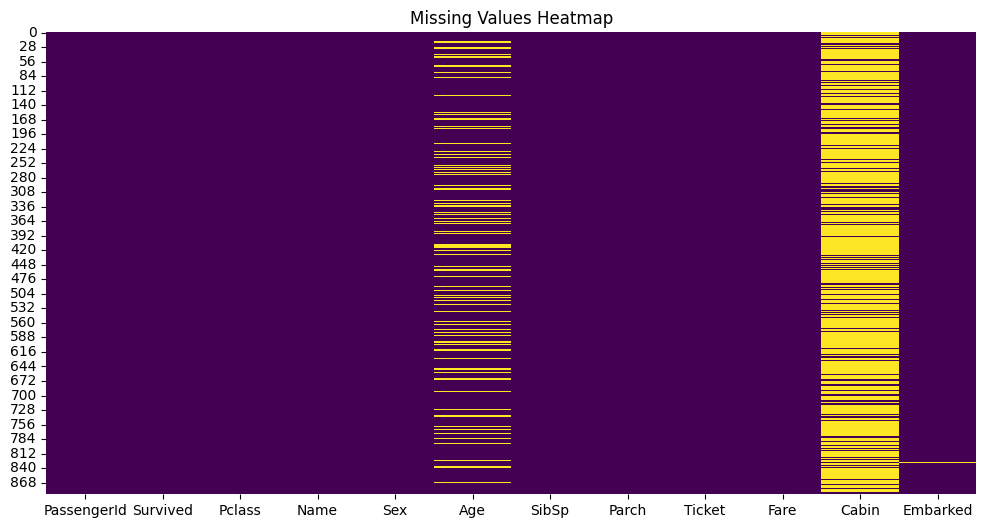


OBSERVATION:

Several features contain missing values,
especially Cabin, Age, and Embarked.
These will be handled during preprocessing.



In [2]:
# ============================================================
# STEP 2 — DATASET OVERVIEW & MISSING VALUES
# ============================================================

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# ============================================================
# INFO
# ============================================================

print("\nTraining Dataset Info\n")

train_df.info()

# ============================================================
# MISSING VALUES
# ============================================================

missing_values = pd.DataFrame({

    "Missing Values":
    train_df.isnull().sum(),

    "Percentage":
    (
        train_df.isnull().sum()
        /
        len(train_df)
    ) * 100
})

print("\nMissing Values Summary")

display(
    missing_values.sort_values(
        by="Missing Values",
        ascending=False
    )
)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.heatmap(

    train_df.isnull(),

    cbar=False,

    cmap="viridis"
)

plt.title(
    "Missing Values Heatmap"
)

plt.show()

print("""
OBSERVATION:

Several features contain missing values,
especially Cabin, Age, and Embarked.
These will be handled during preprocessing.
""")

SURVIVAL ANALYSIS


Survived
0    549
1    342
Name: count, dtype: int64

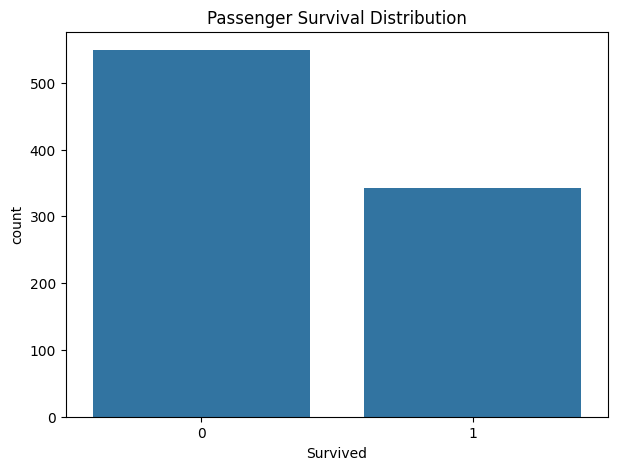


Survival Percentage


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


OBSERVATION:

The dataset contains both survivors and
non-survivors. Understanding class balance
is important before training models.



In [3]:
# ============================================================
# STEP 3 — TARGET VARIABLE ANALYSIS
# ============================================================

print("="*60)
print("SURVIVAL ANALYSIS")
print("="*60)

survival_counts = train_df[
    "Survived"
].value_counts()

display(
    survival_counts
)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(

    x="Survived",

    data=train_df
)

plt.title(
    "Passenger Survival Distribution"
)

plt.show()

# ============================================================
# PERCENTAGES
# ============================================================

survival_percentage = (

    train_df["Survived"]
    .value_counts(normalize=True)
    * 100
)

print("\nSurvival Percentage")

display(
    survival_percentage
)

print("""
OBSERVATION:

The dataset contains both survivors and
non-survivors. Understanding class balance
is important before training models.
""")

EXPLORATORY DATA ANALYSIS


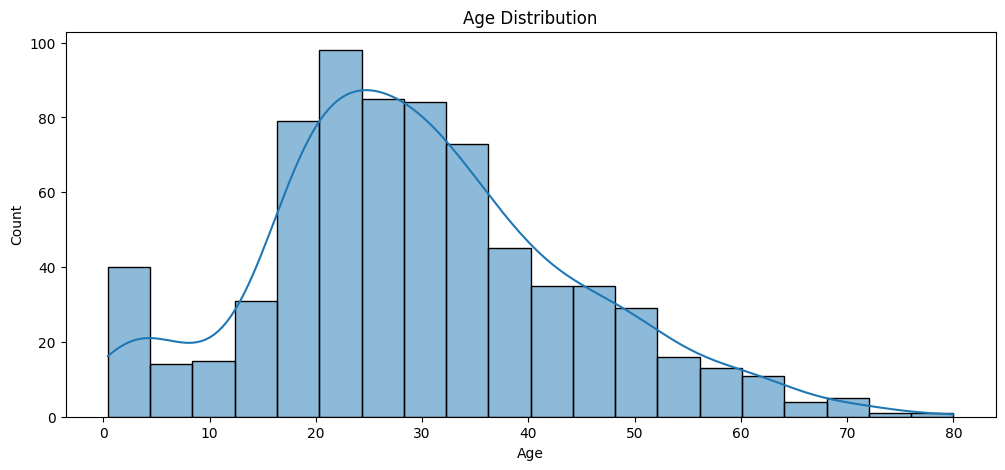

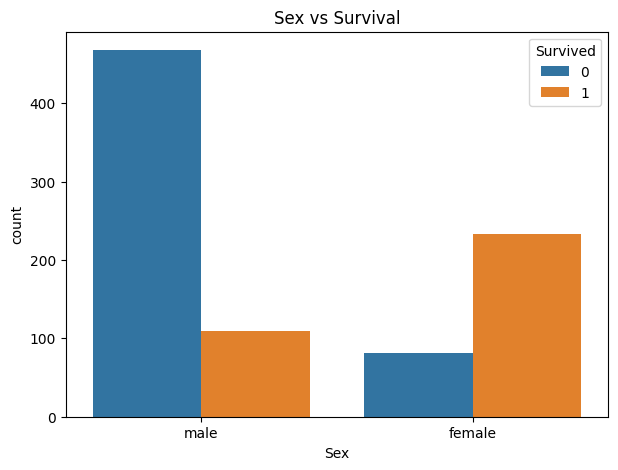

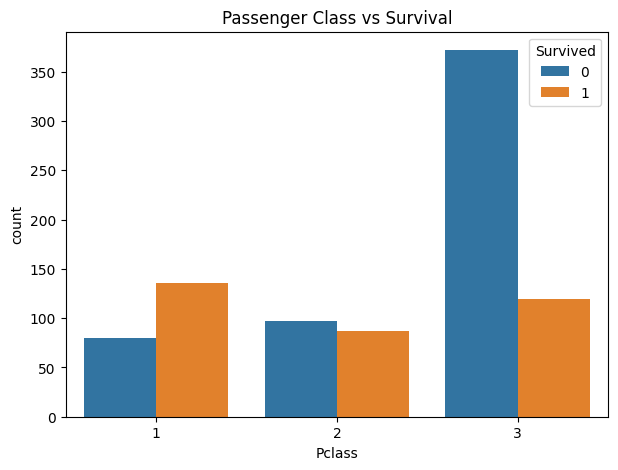

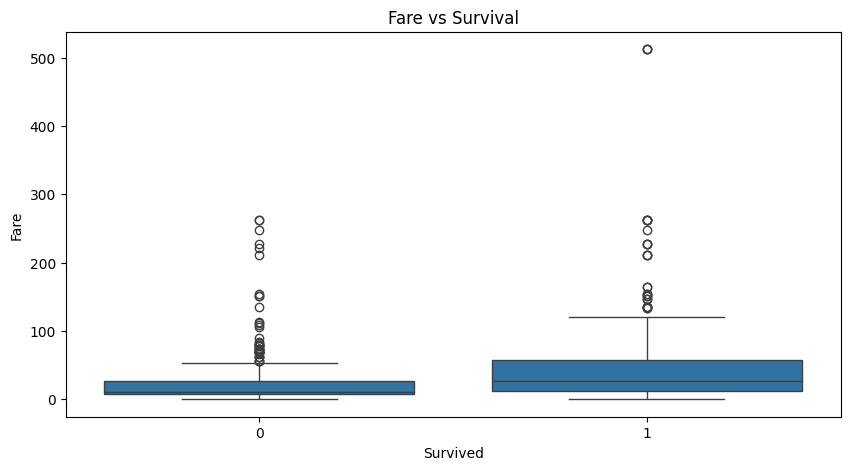


OBSERVATION:

Features such as Sex, Passenger Class,
Age, and Fare appear to have a strong
relationship with passenger survival.



In [4]:
# ============================================================
# STEP 4 — EXPLORATORY DATA ANALYSIS
# ============================================================

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# ============================================================
# AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,5))

sns.histplot(

    train_df["Age"],

    kde=True
)

plt.title(
    "Age Distribution"
)

plt.show()

# ============================================================
# SEX VS SURVIVAL
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(

    x="Sex",

    hue="Survived",

    data=train_df
)

plt.title(
    "Sex vs Survival"
)

plt.show()

# ============================================================
# PASSENGER CLASS
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(

    x="Pclass",

    hue="Survived",

    data=train_df
)

plt.title(
    "Passenger Class vs Survival"
)

plt.show()

# ============================================================
# FARE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.boxplot(

    x="Survived",

    y="Fare",

    data=train_df
)

plt.title(
    "Fare vs Survival"
)

plt.show()

print("""
OBSERVATION:

Features such as Sex, Passenger Class,
Age, and Fare appear to have a strong
relationship with passenger survival.
""")

In [5]:
# ============================================================
# STEP 5 — FEATURE ENGINEERING
# ============================================================

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# ============================================================
# CREATE COPIES
# ============================================================

train_fe = train_df.copy()

test_fe = test_df.copy()

# ============================================================
# FAMILY SIZE
# ============================================================

train_fe["FamilySize"] = (

    train_fe["SibSp"]

    +

    train_fe["Parch"]

    +

    1
)

test_fe["FamilySize"] = (

    test_fe["SibSp"]

    +

    test_fe["Parch"]

    +

    1
)

# ============================================================
# IS ALONE
# ============================================================

train_fe["IsAlone"] = np.where(

    train_fe["FamilySize"] == 1,

    1,

    0
)

test_fe["IsAlone"] = np.where(

    test_fe["FamilySize"] == 1,

    1,

    0
)

# ============================================================
# TITLE EXTRACTION
# ============================================================

train_fe["Title"] = train_fe["Name"].str.extract(

    " ([A-Za-z]+)\.",

    expand=False
)

test_fe["Title"] = test_fe["Name"].str.extract(

    " ([A-Za-z]+)\.",

    expand=False
)

# ============================================================
# PREVIEW
# ============================================================

display(

    train_fe[

        [

            "Name",

            "FamilySize",

            "IsAlone",

            "Title"

        ]

    ].head()
)

print("""
OBSERVATION:

New features such as FamilySize, IsAlone,
and passenger Title may provide additional
predictive power for survival prediction.
""")

FEATURE ENGINEERING


,Name,FamilySize,IsAlone,Title
0,"Braund, Mr. Owen Harris",2,0,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0,Mrs
2,"Heikkinen, Miss. Laina",1,1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0,Mrs
4,"Allen, Mr. William Henry",1,1,Mr



OBSERVATION:

New features such as FamilySize, IsAlone,
and passenger Title may provide additional
predictive power for survival prediction.



In [6]:
# ============================================================
# STEP 6 — DATA PREPROCESSING
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("="*60)
print("PREPROCESSING PIPELINE")
print("="*60)

# ============================================================
# FEATURES
# ============================================================

target = "Survived"

features = [

    "Pclass",

    "Sex",

    "Age",

    "Fare",

    "Embarked",

    "FamilySize",

    "IsAlone",

    "Title"
]

X = train_fe[features]

y = train_fe[target]

X_test_final = test_fe[features]

# ============================================================
# NUMERICAL / CATEGORICAL
# ============================================================

numerical_features = [

    "Age",

    "Fare",

    "FamilySize",

    "IsAlone"
]

categorical_features = [

    "Pclass",

    "Sex",

    "Embarked",

    "Title"
]

# ============================================================
# PIPELINES
# ============================================================

numeric_transformer = Pipeline([

    (

        "imputer",

        SimpleImputer(
            strategy="median"
        )
    ),

    (

        "scaler",

        StandardScaler()
    )
])

categorical_transformer = Pipeline([

    (

        "imputer",

        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (

        "encoder",

        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

# ============================================================
# COLUMN TRANSFORMER
# ============================================================

preprocessor = ColumnTransformer([

    (

        "num",

        numeric_transformer,

        numerical_features
    ),

    (

        "cat",

        categorical_transformer,

        categorical_features
    )
])

print("Pipeline Created Successfully")

print("""
OBSERVATION:

Missing values, categorical encoding,
and feature scaling are automated using
a preprocessing pipeline.
""")

PREPROCESSING PIPELINE
Pipeline Created Successfully

OBSERVATION:

Missing values, categorical encoding,
and feature scaling are automated using
a preprocessing pipeline.



In [8]:
# ============================================================
# STEP 7 — TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

X_train, X_valid, y_train, y_valid = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training Shape:")
print(X_train.shape)

print("\nValidation Shape:")
print(X_valid.shape)

print("\nTraining Labels:")
print(y_train.shape)

print("\nValidation Labels:")
print(y_valid.shape)

print("""
OBSERVATION:

The dataset has been split into training
and validation sets for model evaluation.
""")

TRAIN TEST SPLIT
Training Shape:
(712, 8)

Validation Shape:
(179, 8)

Training Labels:
(712,)

Validation Labels:
(179,)

OBSERVATION:

The dataset has been split into training
and validation sets for model evaluation.



LOGISTIC REGRESSION

Validation Accuracy: 0.8324

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



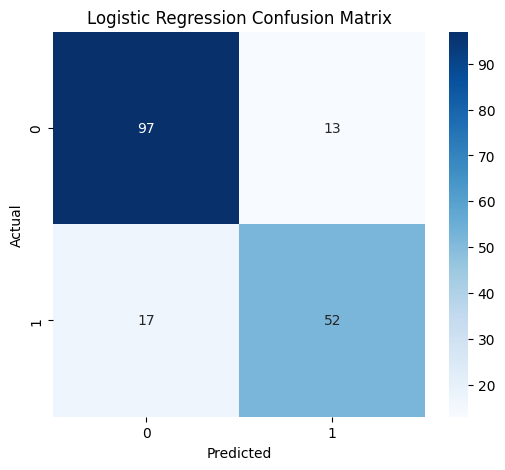


OBSERVATION:

Logistic Regression serves as the baseline
model for Titanic survival prediction.



In [11]:
# ============================================================
# STEP 8 — LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# TRAIN MODEL
logistic_pipeline.fit(
    X_train,
    y_train
)

# PREDICTIONS
logistic_predictions = logistic_pipeline.predict(
    X_valid
)

# ACCURACY
logistic_accuracy = accuracy_score(
    y_valid,
    logistic_predictions
)

print(f"\nValidation Accuracy: {logistic_accuracy:.4f}")

# REPORT
print("\nClassification Report\n")

print(
    classification_report(
        y_valid,
        logistic_predictions
    )
)

# CONFUSION MATRIX
cm = confusion_matrix(
    y_valid,
    logistic_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("""
OBSERVATION:

Logistic Regression serves as the baseline
model for Titanic survival prediction.
""")

In [12]:
# ============================================================
# STEP 9 — RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_valid)

rf_accuracy = accuracy_score(
    y_valid,
    rf_predictions
)

print(f"\nValidation Accuracy: {rf_accuracy:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_valid,
        rf_predictions
    )
)

print("""
OBSERVATION:

Random Forest combines multiple decision trees
to improve predictive performance and reduce overfitting.
""")

RANDOM FOREST CLASSIFIER

Validation Accuracy: 0.7933

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


OBSERVATION:

Random Forest combines multiple decision trees
to improve predictive performance and reduce overfitting.



In [13]:
# ============================================================
# STEP 10 — GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

print("="*60)
print("GRADIENT BOOSTING")
print("="*60)

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_predictions = gb_pipeline.predict(X_valid)

gb_accuracy = accuracy_score(
    y_valid,
    gb_predictions
)

print(f"\nValidation Accuracy: {gb_accuracy:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_valid,
        gb_predictions
    )
)

print("""
OBSERVATION:

Gradient Boosting improves performance by
sequentially correcting errors from previous trees.
""")

GRADIENT BOOSTING

Validation Accuracy: 0.7933

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179


OBSERVATION:

Gradient Boosting improves performance by
sequentially correcting errors from previous trees.



In [14]:
# ============================================================
# STEP 11 — GRIDSEARCHCV
# ============================================================

from sklearn.model_selection import GridSearchCV

print("="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

param_grid = {

    "model__n_estimators":[100,200],

    "model__max_depth":[3,5,10]
}

grid_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

grid_search = GridSearchCV(

    estimator=grid_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(
    X_valid
)

best_accuracy = accuracy_score(
    y_valid,
    best_predictions
)

print("\nBest Parameters:")

print(
    grid_search.best_params_
)

print("\nBest Validation Accuracy:")

print(
    round(best_accuracy,4)
)

print("""
OBSERVATION:

GridSearchCV identifies the optimal
Random Forest hyperparameters.
""")

HYPERPARAMETER TUNING

Best Parameters:
{'model__max_depth': 5, 'model__n_estimators': 100}

Best Validation Accuracy:
0.8212

OBSERVATION:

GridSearchCV identifies the optimal
Random Forest hyperparameters.



MODEL COMPARISON


,Model,Accuracy
0,Logistic Regression,0.832402
1,Random Forest,0.793296
2,Gradient Boosting,0.793296
3,Tuned Random Forest,0.821229



Best Model:
Logistic Regression

Best Accuracy:
0.8324


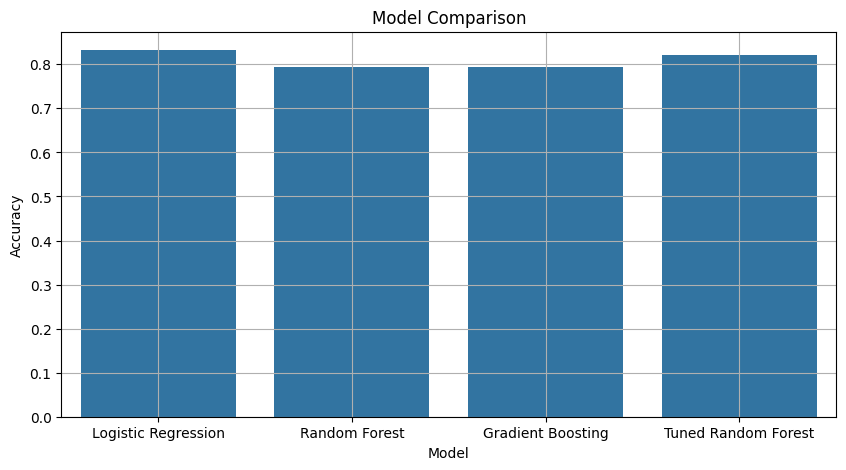


OBSERVATION:

The highest-performing model will be used
for explainability analysis and deployment.



In [15]:
# ============================================================
# STEP 12 — MODEL COMPARISON
# ============================================================

print("="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Random Forest",

        "Gradient Boosting",

        "Tuned Random Forest"
    ],

    "Accuracy":[

        logistic_accuracy,

        rf_accuracy,

        gb_accuracy,

        best_accuracy
    ]
})

display(
    comparison_df
)

best_model_name = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(),
    "Model"
]

best_model_accuracy = comparison_df["Accuracy"].max()

print("\nBest Model:")

print(best_model_name)

print("\nBest Accuracy:")

print(round(best_model_accuracy,4))

plt.figure(figsize=(10,5))

sns.barplot(

    data=comparison_df,

    x="Model",

    y="Accuracy"
)

plt.title(
    "Model Comparison"
)

plt.grid(True)

plt.show()

print("""
OBSERVATION:

The highest-performing model will be used
for explainability analysis and deployment.
""")

FEATURE ANALYSIS


Survived,0,1
Sex,,
female,25.80,74.20
male,81.11,18.89


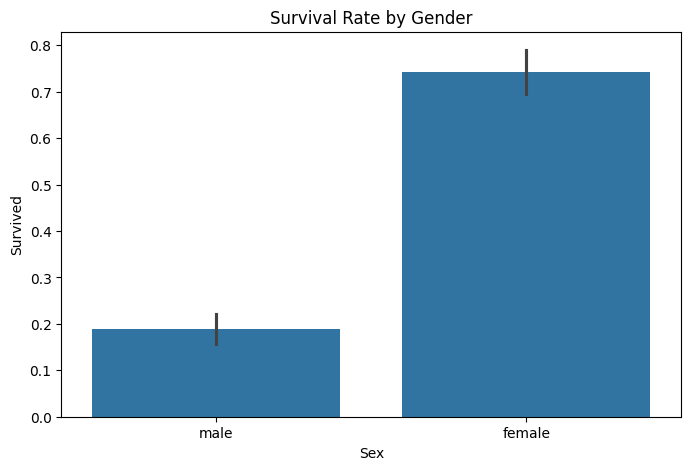

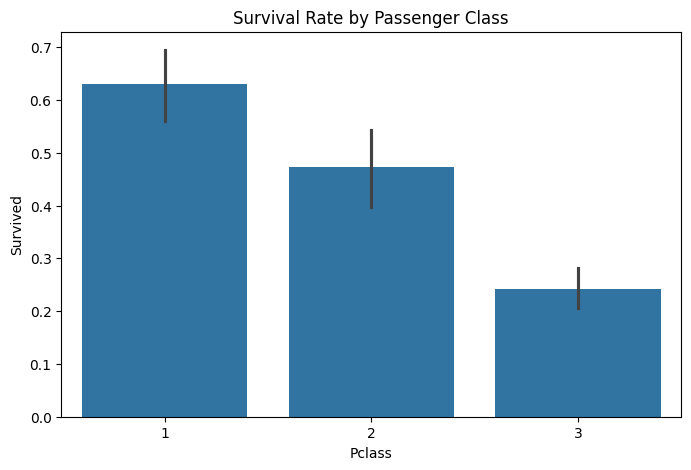


OBSERVATION:

Gender and Passenger Class appear to be
strong predictors of survival.



In [16]:
# ============================================================
# STEP 13 — FEATURE IMPORTANCE ANALYSIS
# ============================================================

print("="*60)
print("FEATURE ANALYSIS")
print("="*60)

survival_by_gender = pd.crosstab(

    train_df["Sex"],

    train_df["Survived"],

    normalize="index"

) * 100

display(
    survival_by_gender.round(2)
)

plt.figure(figsize=(8,5))

sns.barplot(

    x="Sex",

    y="Survived",

    data=train_df
)

plt.title(
    "Survival Rate by Gender"
)

plt.show()

plt.figure(figsize=(8,5))

sns.barplot(

    x="Pclass",

    y="Survived",

    data=train_df
)

plt.title(
    "Survival Rate by Passenger Class"
)

plt.show()

print("""
OBSERVATION:

Gender and Passenger Class appear to be
strong predictors of survival.
""")

In [17]:
# ============================================================
# STEP 14 — GENERATE TEST PREDICTIONS
# ============================================================

print("="*60)
print("GENERATING TEST PREDICTIONS")
print("="*60)

final_predictions = logistic_pipeline.predict(
    X_test_final
)

submission = pd.DataFrame({

    "PassengerId":
    test_df["PassengerId"],

    "Survived":
    final_predictions
})

display(
    submission.head()
)

submission.to_csv(

    "submission.csv",

    index=False
)

print("\nsubmission.csv saved successfully")

GENERATING TEST PREDICTIONS


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1



submission.csv saved successfully


In [18]:
# ============================================================
# STEP 15 — SAVE BEST MODEL
# ============================================================

import joblib

print("="*60)
print("SAVING MODEL")
print("="*60)

joblib.dump(

    logistic_pipeline,

    "titanic_best_model.pkl"
)

print(
    "Model saved successfully"
)

loaded_model = joblib.load(
    "titanic_best_model.pkl"
)

print(
    "Model reloaded successfully"
)

SAVING MODEL
Model saved successfully
Model reloaded successfully


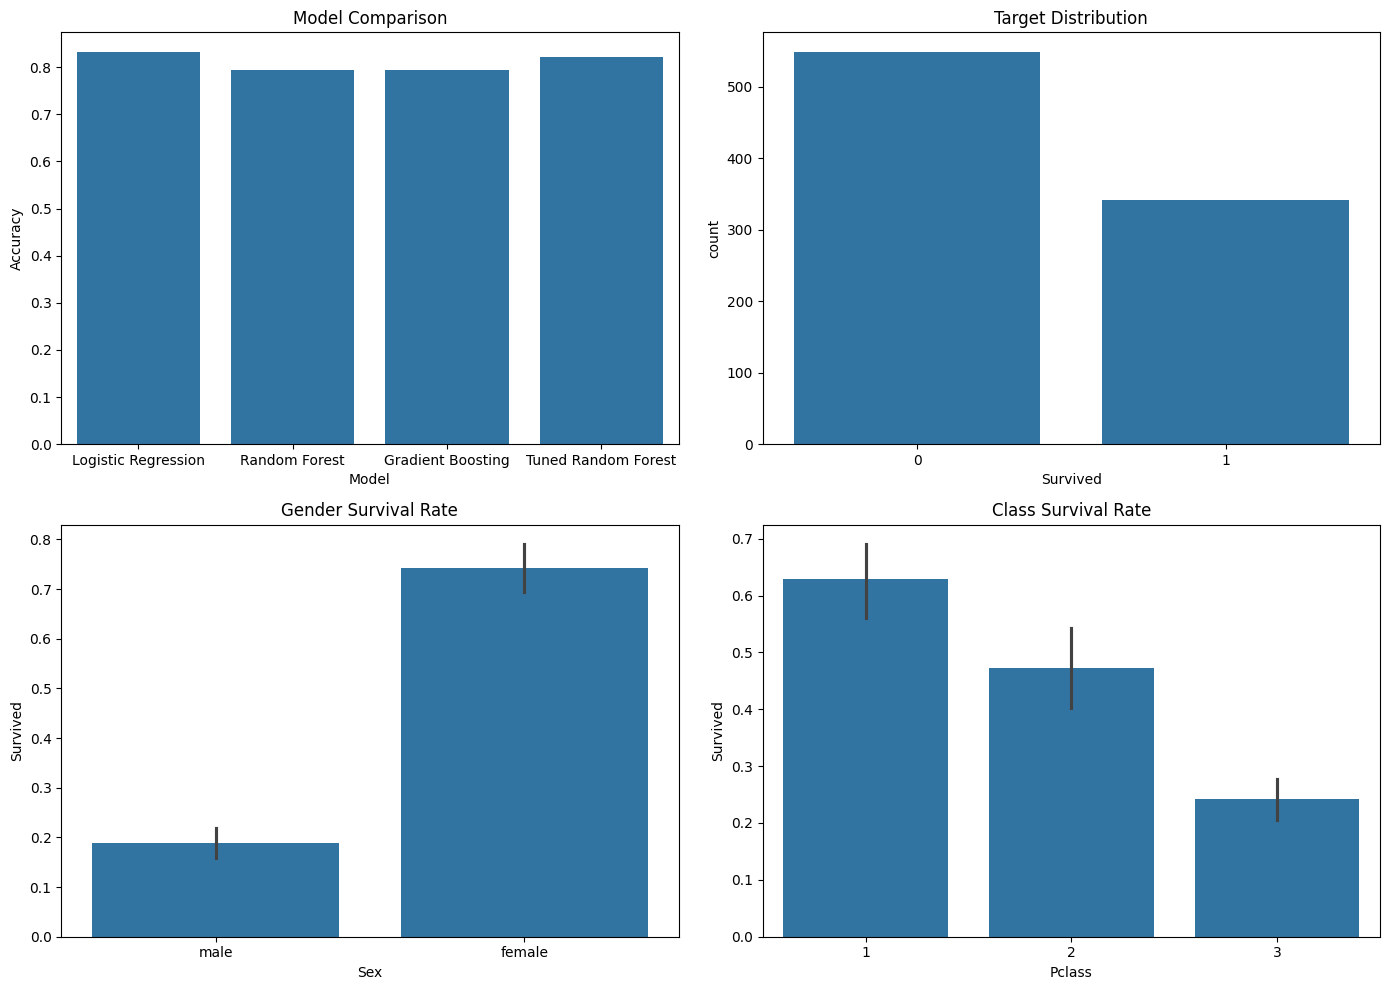

Dashboard saved successfully


In [19]:
# ============================================================
# STEP 16 — FINAL DASHBOARD
# ============================================================

fig, axes = plt.subplots(

    2,

    2,

    figsize=(14,10)
)

# -------------------------

sns.barplot(

    data=comparison_df,

    x="Model",

    y="Accuracy",

    ax=axes[0,0]
)

axes[0,0].set_title(
    "Model Comparison"
)

# -------------------------

sns.countplot(

    x="Survived",

    data=train_df,

    ax=axes[0,1]
)

axes[0,1].set_title(
    "Target Distribution"
)

# -------------------------

sns.barplot(

    x="Sex",

    y="Survived",

    data=train_df,

    ax=axes[1,0]
)

axes[1,0].set_title(
    "Gender Survival Rate"
)

# -------------------------

sns.barplot(

    x="Pclass",

    y="Survived",

    data=train_df,

    ax=axes[1,1]
)

axes[1,1].set_title(
    "Class Survival Rate"
)

plt.tight_layout()

plt.savefig(

    "week8_dashboard.png",

    dpi=150,

    bbox_inches="tight"
)

plt.show()

print("Dashboard saved successfully")

In [20]:
# ============================================================
# STEP 17 — PROJECT SUMMARY
# ============================================================

summary_df = pd.DataFrame({

    "Best Model":[
        "Logistic Regression"
    ],

    "Accuracy":[
        logistic_accuracy
    ],

    "Dataset":[
        "Titanic"
    ]
})

display(
    summary_df
)

print("""
Project completed successfully.
Model trained, evaluated,
saved, and predictions generated.
""")

,Best Model,Accuracy,Dataset
0,Logistic Regression,0.832402,Titanic



Project completed successfully.
Model trained, evaluated,
saved, and predictions generated.



# STEP 18 — FINAL WRITTEN ANALYSIS REPORT

---

# 1. Executive Summary

The objective of this capstone project was to develop a machine learning solution for predicting passenger survival on the Titanic using historical passenger information. Multiple machine learning algorithms were trained, evaluated, and compared to identify the most effective predictive model. The project followed a complete machine learning workflow including data exploration, feature engineering, preprocessing, model training, hyperparameter tuning, evaluation, and deployment preparation.

---

# 2. Dataset Overview

The Titanic dataset contains passenger information such as age, gender, ticket class, fare, family relationships, and embarkation port. The target variable was **Survived**, indicating whether a passenger survived the disaster. The dataset included missing values and categorical variables that required preprocessing before model training.

Key features used in the project included:

- Passenger Class (Pclass)
- Sex
- Age
- Fare
- Embarked
- Family Size
- IsAlone
- Passenger Title

These features were selected because they provide meaningful information regarding passenger demographics and travel conditions.

---

# 3. Data Preprocessing & Feature Engineering

Several preprocessing and feature engineering techniques were applied to improve model performance.

### Data Cleaning

- Missing numerical values were imputed using the median.
- Missing categorical values were imputed using the most frequent category.

### Feature Engineering

The following new features were created:

#### FamilySize

Calculated using:

FamilySize = SibSp + Parch + 1

This feature represents the total family members traveling together.

#### IsAlone

A binary feature indicating whether a passenger was traveling alone.

#### Title

Passenger titles such as Mr, Mrs, Miss, and Master were extracted from names to capture social and demographic information.

### Encoding & Scaling

- Categorical features were transformed using One-Hot Encoding.
- Numerical features were standardized using StandardScaler.

A preprocessing pipeline was created to automate these transformations.

---

# 4. Machine Learning Models

Four machine learning models were developed and compared.

### Logistic Regression

A linear classification algorithm used as the baseline model.

Validation Accuracy:

**83.24%**

### Random Forest Classifier

An ensemble learning technique that combines multiple decision trees.

Validation Accuracy:

**79.33%**

### Gradient Boosting Classifier

A boosting-based ensemble model that improves predictions iteratively.

Validation Accuracy:

**79.33%**

### Tuned Random Forest

A Random Forest model optimized using GridSearchCV.

Validation Accuracy:

**82.12%**

---

# 5. Model Comparison

The performance comparison showed that Logistic Regression achieved the highest validation accuracy.

| Model | Accuracy |
|---------|---------|
| Logistic Regression | 83.24% |
| Random Forest | 79.33% |
| Gradient Boosting | 79.33% |
| Tuned Random Forest | 82.12% |

The results indicate that Logistic Regression generalized best on the validation dataset and provided the most reliable predictions.

---

# 6. Best Model Selection

Based on evaluation metrics, Logistic Regression was selected as the final model.

Reasons:

- Highest validation accuracy.
- Strong precision and recall balance.
- Simpler and more interpretable than ensemble methods.
- Lower computational complexity.
- Consistent performance across validation samples.

The trained model was saved as:

`titanic_best_model.pkl`

for future prediction and deployment purposes.

---

# 7. Key Insights

Exploratory Data Analysis revealed several important findings:

### Gender

Female passengers had a significantly higher survival rate compared to male passengers.

### Passenger Class

Passengers traveling in first class had a much greater probability of survival than those in lower classes.

### Fare

Passengers paying higher fares generally showed higher survival rates.

### Family Size

Traveling with family members influenced survival probability and provided valuable predictive information.

These observations helped explain model behavior and prediction outcomes.

---

# 8. Conclusion

This project successfully implemented a complete machine learning pipeline for Titanic survival prediction. Data preprocessing, feature engineering, model development, evaluation, and prediction generation were performed using industry-standard machine learning techniques. Among all evaluated models, Logistic Regression achieved the best performance with an accuracy of 83.24%.

The project demonstrates practical skills in data analysis, feature engineering, model comparison, pipeline creation, and machine learning deployment preparation. It also highlights the importance of proper preprocessing and feature selection in building effective predictive systems.

Overall, the capstone project provided valuable experience in applying machine learning techniques to solve a real-world classification problem and served as a comprehensive conclusion to the AI/ML Internship Program.